TASK: INSIGHTS AND CONCLUSIONS

6.1--> Identify any trends or patterns in transactions data.

------TOTAL TRANSACTIONS TREND------

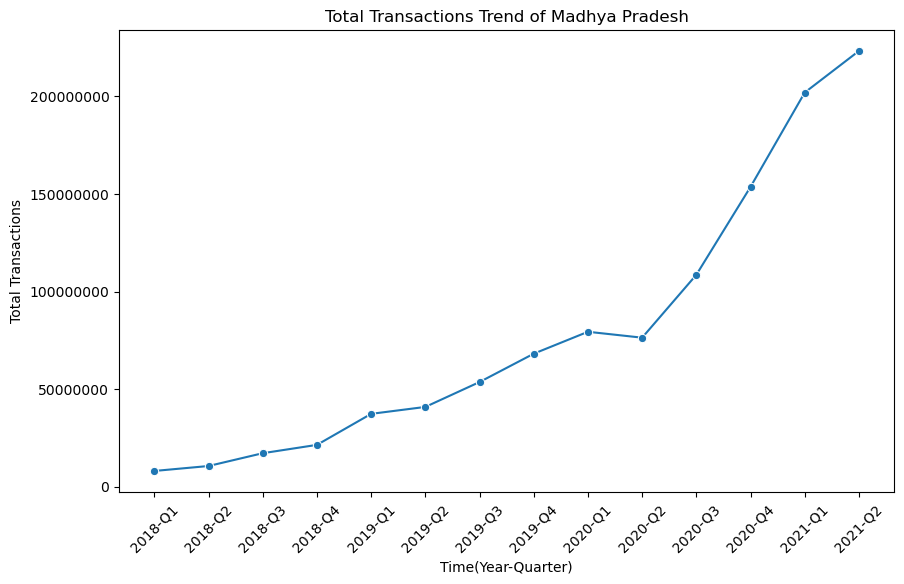

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
my_state='Madhya Pradesh'

# AGGREGATE 
res=s_txnusers.groupby(['State','Year','Quarter']).agg({
    'Transactions':'sum',
    'Amount (INR)':'sum'}).reset_index()

# MAKE A COLUMN FOR TIME (YEAR-QUARTER)
res=res[res['State']==my_state]
res=res.sort_values(['Year','Quarter'])
res['Time']=res['Year'].astype(str)+'-Q'+res['Quarter'].astype(str)

# PLOT TOTAL TRANSACTIONS OVER TIME
plt.figure(figsize=(10,6))
sns.lineplot(data=res,x='Time',y='Transactions',marker='o')
plt.title(f'Total Transactions Trend of {my_state}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('Total Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=45)
plt.show()

-------TOTAL AMOUNT TREND-------

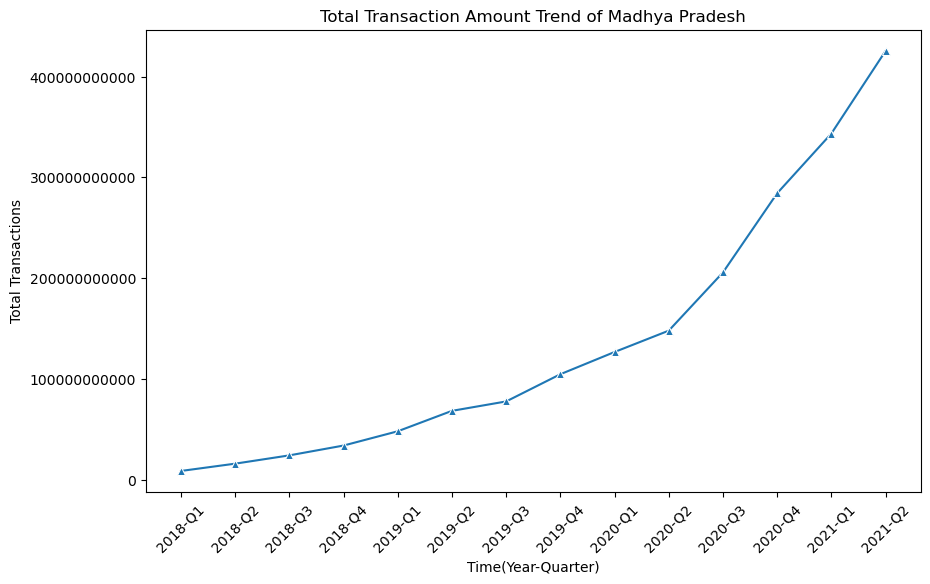

In [10]:
# PLOT TOTAL TRANSACTION AMOUNT OVER TIME
plt.figure(figsize=(10,6))
sns.lineplot(data=res,x='Time',y='Amount (INR)',marker='^')
plt.title(f'Total Transaction Amount Trend of {my_state}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('Total Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=45)
plt.show()

-------APP USAGE TREND-------

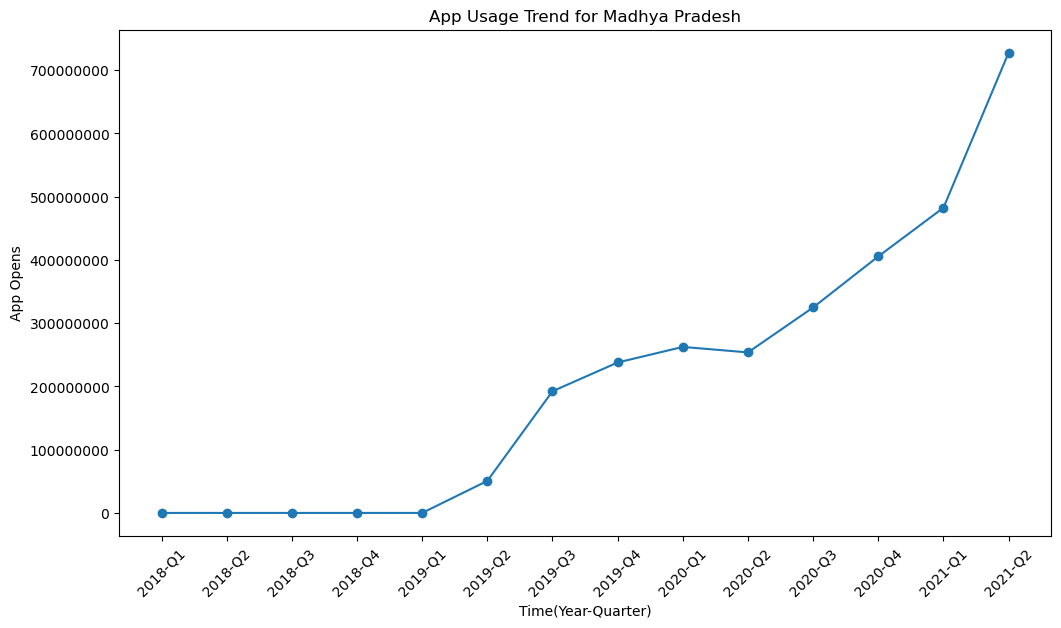

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
res=s_txnusers.groupby(['State','Year','Quarter'])['App Opens'].sum().reset_index()

# TIME BASED DATA FOR A SELECTED STATE
state_name='Madhya Pradesh'
df_state=res[res['State']==state_name].copy()
df_state['Time']=df_state['Year'].astype(str)+'-Q' + df_state['Quarter'].astype(str)
df_state=df_state.sort_values(['Year','Quarter'])

# PLOT A LINE CHART
plt.figure(figsize=(10,6))
plt.plot(df_state['Time'],df_state['App Opens'],marker='o')
plt.title(f'App Usage Trend for {state_name}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('App Opens')
plt.tight_layout()
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain',axis='y')  # to remove scientific notation
plt.show()

-------TRANSACTION TYPE DISTRIBUTION FOR MP-----------

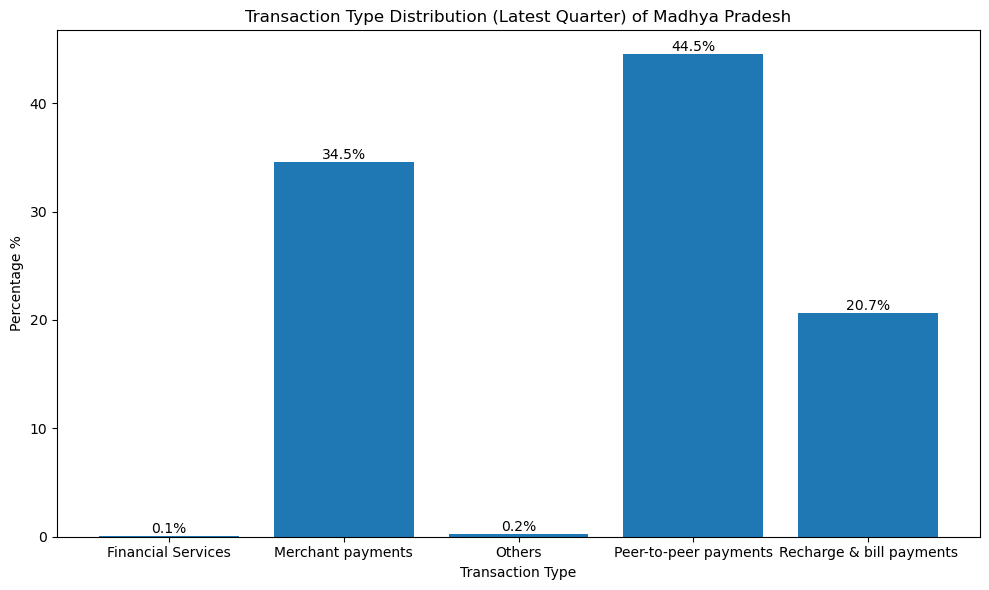

In [4]:
import pandas as pd
s_txnsplit=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_TxnSplit')
latest_year=s_txnsplit['Year'].max()
latest_quarter=s_txnsplit[s_txnsplit['Year']==latest_year]['Quarter'].max()

# FILTER THE DATA FOR THE LATEST YEAR AND QUARTER
latest_data=s_txnsplit[(s_txnsplit['Year']==latest_year) & (s_txnsplit['Quarter']==latest_quarter)]

# Aggregate
fdata=latest_data.groupby(['State','Transaction Type'])['Transactions'].sum().reset_index()
                     
# For a specific state
state_name='Madhya Pradesh'
fdata=fdata[fdata['State']==state_name]
fdata['Percentage']=(fdata['Transactions']/fdata['Transactions'].sum()*100)

# PLOT A SPECIFIC BAR CHART
plt.figure(figsize=(10,6))
bars=plt.bar(fdata['Transaction Type'],fdata['Percentage'])

# for data labels on the top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.1f}%',
             ha='center',
             va='bottom')
plt.title(f'Transaction Type Distribution (Latest Quarter) of {state_name}')
plt.xlabel('Transaction Type')
plt.ylabel('Percentage %')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

6.2--> Correlate demographic data with transaction data.

The Correlation between Population Density and Transactions is: 0.048465001743023844.


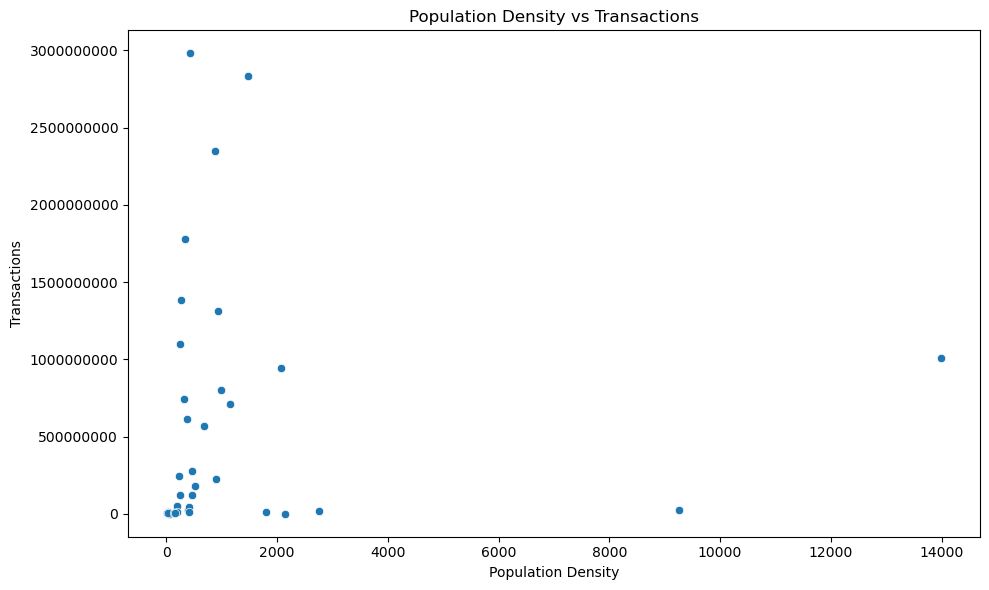

In [7]:
import pandas as pd
import seaborn as sns
d_demo=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='District Demographics')
# AGGREGATE THE TOTAL POPULATION DENSITY BY STATE
pdn=d_demo.groupby('State')['Density'].mean().reset_index()

# AGGREGATE THE TRANSACTIONS BY STATE
tst=s_txnusers.groupby('State')['Transactions'].sum().reset_index()

# MERGE BOTH DATASETS
merged=pdn.merge(tst,on='State')

# FIND CORRELATION BETWEEN DENSITY AND TRANSACTIONS
corr=merged['Density'].corr(merged['Transactions'])
print(f"The Correlation between Population Density and Transactions is: {corr}.")

# PLOT SCATTER PLOT
plt.figure(figsize=(10,6))
sns.scatterplot(data=merged,x='Density',y='Transactions')
plt.title('Population Density vs Transactions')
plt.xlabel('Population Density')
plt.ylabel('Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

6.3--> KEY FINDINGS AND INSIGHTS

-------------------------------------KEY FINDINGS & INSIGHTS-------------------------------------

1. Transaction Growth Trends.
-->Transactions and app opens show a consistent upward trend over time
-->Growth is not uniform → some quarters spike (likely seasonal or campaign-driven)

Insight:
User adoption is increasing, but engagement is uneven.

2. State-Level Variations.
->Some states dominate in:
-->Total transactions (volume)
-->Total amount (value)
->Others have lower volume but higher Avg Transaction Value (AvgTV)

Insight:
High volume ≠ high value.
Different states show different user behavior patterns.

3. Avg Transaction Value (AvgTV).
-->States with fewer users sometimes show higher AvgTV
-->Indicates:
--->Higher spending users.
--->Possibly urban or high-income regions.

Insight:
There are premium vs mass-market states.

4. Transaction Type Distribution.
-->A few transaction types dominate (e.g., P2P, recharge, merchant payments).
-->Distribution is not balanced

Insight:
User behavior is concentrated, not diversified.

5. Device Brand Usage.
-->Clear dominance of a few brands (e.g., Xiaomi, Samsung, Vivo)
-->Brand preference varies by state

Insight:
Device ecosystem is region-specific.

6. Population Density vs Transactions.
-->Weak to moderate correlation
-->High density ≠ always high transactions

Insight:
Population alone does NOT drive usage
→ digital adoption matters more

7. Data Discrepancies (State vs District).
-->Differences observed in:
->Amount

Insight:

Possible data quality issues.
Or aggregation mismatch (time / missing districts)

--------------------------------------------RECOMMENDATIONS-----------------------------------------

1. Focus on High-Value States

->Identify states with high AvgTV
Action:
Target premium offers.
Promote high-value financial services

2. Improve Low-Engagement States

->States with low transactions but decent population

Action:

Increase awareness campaigns.
Improve onboarding UX.
Offer incentives (cashbacks).

3. Optimize by Transaction Type

-> If P2P dominates:

Action:

Push merchant payments & financial services.
Diversify usage → increase revenue streams.

4. Device-Based Strategy

->Dominant brands differ per state

Action:

Optimize app performance for top devices.
Run brand-specific campaigns.

5. Don’t Rely on Population Alone

-->Weak correlation found

Action:

Focus on:
Internet penetration.
Digital literacy.
Urbanization.

6. Time-Based Strategy (Very Important)

->Usage varies by quarter

Action:

Identify peak quarters.
Launch campaigns before high-activity periods.
Plan capacity scaling accordingly.